In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data

In [5]:
#unzip the data
!unzip dataset.zip

Archive:  dataset.zip
  inflating: README.txt              
  inflating: all_negative_3307.txt   
  inflating: all_positive_8500.txt   


In [6]:
# read negative texts
with open('/content/all_negative_3307.txt','r',encoding='utf-8') as f:
  neg_texts=f.readlines()

In [8]:
#read positive texts
with open('/content/all_positive_8500.txt','r',encoding='utf-8') as f:
  pos_texts=f.readlines()

In [18]:
neg_texts=[text.strip() for text in neg_texts]

In [19]:
pos_texts=[text.strip() for text in pos_texts]

In [20]:
texts=neg_texts+pos_texts

In [26]:
len(texts)

11807

In [37]:
neg_labels=[0]*len(neg_texts)
pos_lebels=[1]* len(pos_texts)

In [38]:
labels=neg_labels+pos_lebels

In [40]:
len(labels)

11807

In [41]:
df=pd.DataFrame(
    {'text':texts,
     'label':labels}
)
df.head()

,text,label
0,আমার জীবনের সবথেকে ফালতু একটা নাটক এইটা,0
1,সাধারণ মানুষ টিভি চ্যানেল গুলো ছুড়ে ফেলে দিয়ে...,0
2,স্টুডেন্ট ওরে একটা থাপ্পড় মারো,0
3,নাটকটিতে কথা থেকে মিউজিকের সাউন্ডটা বেশি হয়ে গ...,0
4,পাকনা মেয়াটা একটা বাজে,0


In [42]:
df.tail()

,text,label
11802,নাটকটার এড দেখে বুঝতে পারছি অনেক ভালো লাগবে,1
11803,তিশাকে চশমায় সেই লাগে,1
11804,বাংলা নাটক মানেই মনের মধ্যে একটা অন্যরকম অনুভূ...,1
11805,"দেখা শুরু করলাম,, ভাল না হয়ে যাবে কই অপূর্ব বল...",1
11806,শুধু এই নাটকের জন্য চ্যানেলটি সাবস্ক্রাইব করলাম,1


In [46]:
# suffle data
df=df.sample(frac=1,random_state=42).reset_index(drop=True)

In [47]:
df.head()

,text,label
0,অসাধারণ লাগলো,1
1,জীবনে প্রথম তানজীন তিশার কোন ভাল নাটক দেখলাম,1
2,আজাইরা বিষয়বস্তু!!!,0
3,আমাদের দেশের নাটক গুলো ভালো। আর ও ভালো লাগবে ন...,1
4,খুব সুন্দর নাটক।,1


In [48]:
df.tail()

,text,label
11802,"সত্যিই নাটকটি সুন্দর ছিল,,,,,,,মাবরুর রশিদ বান...",1
11803,অনেকদিন পরে চমৎকার একটি নাটক দেখলামফ্যামিলি সহ...,1
11804,অসাধারণ নাটক তবে সব থেকে ভালো লেগেছে নামাজ নিয...,1
11805,বাংলা নাটক গুলো বছর আগের চালচিত্রের মত অশ্লী...,0
11806,বর্তমানে বাংলাদেশের সবচেয়ে জনপ্রিয় নাটক অভিনেত...,1


In [49]:
df['label'].value_counts()

,count
label,
1,8500
0,3307


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11807 entries, 0 to 11806
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    11807 non-null  object
 1   label   11807 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 184.6+ KB


# Data Cleaning

In [68]:
import re

def clean_text(text):

    # Convert to string
    text = str(text)

    # Remove English letters
    text = re.sub(r'[a-zA-Z]', ' ', text)

    # Remove numbers (English + Bangla)
    text = re.sub(r'[0-9০-৯]', ' ', text)

    # Keep only Bangla characters and spaces
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [70]:
text = "I ❤️ বাংলাদেশ!!! ২০২6 সালে AI শিখবো!!! 123"

cleaned = clean_text(text)

print(cleaned)

বাংলাদেশ সালে শিখবো


In [71]:
df['text']=df['text'].apply(clean_text)

In [73]:
df.sample(10)

,text,label
7117,বাল বানাও মাদারচোদেরা,0
266,এক কথায় অসাধারণ কেনো জানি চোখে পানি চলে আসলো,1
10877,বাংলাদেশী নাটক হলো বিশ্বের সর্বশ্রেষ্ঠ নাটক আর...,1
4913,তানজিন তিশাকে অাগে ভালোই লাগতো ইদানিং অাফরান ন...,0
2726,চোট্টা শাকিরা,0
10094,অনেকদিন পর খুব ভালো একটা নাটক দেখলাম প্রতিবার ...,1
6125,সালের সেরা নাটক,1
6106,ফালতু নাটক,0
7287,অনেক অনেক সুন্দর হয়ছে ধন্যবাদ ওমি ভাই আপনার জন...,1
8759,সব ই পাগল পাগলের দল পরিচালক প্রযোযগ সব পাগল,0


In [74]:
bangla_stopwords = {
    "আমি", "আমাকে", "আমার", "আমরা", "আমাদের", "তুমি", "তোমাকে", "তোমার", "আপনি", "আপনার",
    "সে", "তাকে", "তার", "তারা", "তাদের", "তিনি", "তাঁকে", "তাঁর", "এবং", "ও", "আর", "কিন্তু",
    "অথবা", "অথচ", "নাকি", "কিংবা", "কারণ", "তাই", "তবে", "হয়", "হওয়া", "হয়েছে", "আছে", "ছিল",
    "না", "নেই", "নাই", "করা", "করার", "করে", "করেই", "জন্য", "থেকে", "পর্যন্ত", "মধ্যে", "এই",
    "এটি", "এটা", "ঐ", "ওই", "কোন", "কোনো", "কিছু", "খুব", "নিজে", "নিজের", "এর", "তে", "কে"
}

In [79]:
# remove stop words
def remove_stopwords(text):
  words=text.split()

  filtered_words=[
      word
      for word in words
      if word not in bangla_stopwords
  ]

  return " ".join(filtered_words)

In [80]:
df['text']=df['text'].apply(remove_stopwords)

# Train Test Split

In [84]:
X=df['text']
y=df['label']

In [85]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.2,
                                               random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((9445,), (2362,), (9445,), (2362,))

# Model

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


In [87]:
logistic_model=Pipeline(
    [
        ('tfidf',TfidfVectorizer(ngram_range=(1,2),
                                 max_features=50000)),
        ('clf',LogisticRegression(max_iter=1000))
    ]
)

In [88]:
logistic_model.fit(X_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000))])

In [91]:
y_pred=logistic_model.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [92]:
accuracy_score(y_test,y_pred)

0.8738357324301439

In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.66      0.73       628
           1       0.88      0.95      0.92      1734

    accuracy                           0.87      2362
   macro avg       0.86      0.80      0.83      2362
weighted avg       0.87      0.87      0.87      2362



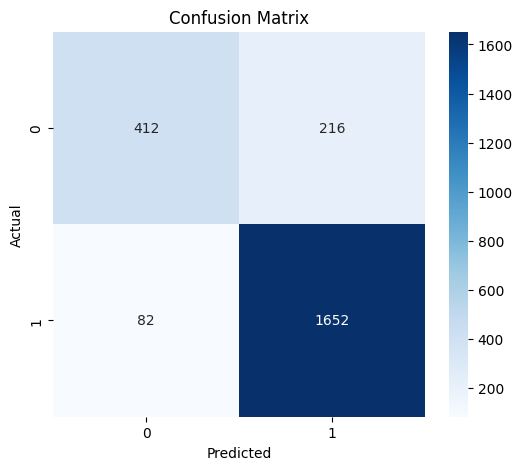

In [99]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [100]:
# naive bayes
from sklearn.naive_bayes import MultinomialNB
nb_model=Pipeline(
    [
        ('tfidf',TfidfVectorizer(ngram_range=(1,2),
                                 max_features=50000)),
        ('clf',MultinomialNB())

    ]
)

In [101]:
nb_model.fit(X_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', MultinomialNB())])

In [104]:
y_predn=nb_model.predict(X_test)

In [105]:
accuracy_score(y_test,y_predn)

0.8399661303979679

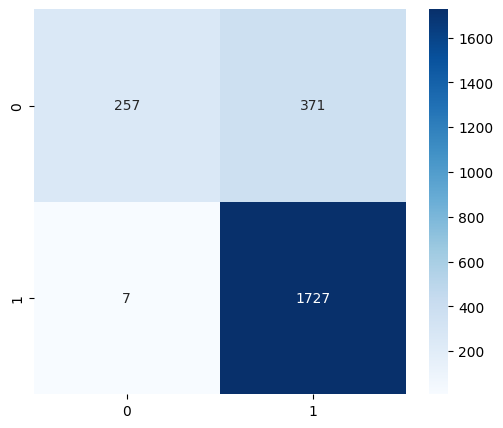

In [106]:
cm = confusion_matrix(y_test, y_predn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

In [107]:
# save best model
import joblib

In [108]:
joblib.dump(logistic_model,"banglasentimentmodel.pkl")
print("Model saved Successfully")

Model saved Successfully


# Load Saved Model

In [109]:
model=joblib.load('/content/banglasentimentmodel.pkl')
model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000))])

In [118]:
text="সময় নষ্ট ফালতু টিম"
text=clean_text(text)
text=remove_stopwords(text)
prediction=model.predict([text])[0]
if prediction == 1:
  print("Positive")
if prediction ==0 :
  print("Negative")

Negative


np.int64(1)

In [ ]:
i